# EDA — End-to-End Data Audit (Raw → Processed → Analytics)

Ce notebook effectue une **analyse complète de la qualité et de la couverture des données** à travers toutes les couches du pipeline :

1. **Données brutes de scraping** (`data/FINAL_sport_fitness_products.csv`)
2. **Datasets traités** (`data/*.parquet`)
3. **Outputs analytics** (`analytics/*.csv`, `*.json`, `*.jsonl`)

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

# ── Chemins adaptés à la structure de ce projet ──────────────────────────────
ROOT      = Path('..').resolve()          # Racine smart_ecommerce/
DATA      = ROOT / 'data'
ANALYTICS = ROOT / 'analytics'

# Alias pour compatibilité avec le notebook des collègues
BASE           = DATA
PROCESSED_DIR  = DATA
ANALYTICS_DIR  = ANALYTICS

# Fichiers clés de ce projet
MAIN_CSV       = DATA / 'FINAL_sport_fitness_products.csv'
SCORED_PARQUET = DATA / 'scored_products.parquet'
CLEAN_PARQUET  = DATA / 'clean_products.parquet'
FEAT_PARQUET   = DATA / 'featured_products.parquet'
TOPK_CSV       = DATA / 'top_k_products.csv'

print('Racine projet :', ROOT)
print('data/    existe :', DATA.exists())
print('analytics/ existe :', ANALYTICS.exists())
print()
print('Fichiers data/ :', [p.name for p in DATA.glob('*') if p.is_file()][:10])
print('Fichiers analytics/ :', [p.name for p in ANALYTICS.glob('*') if p.is_file()][:15])


def safe_read_json(path: Path):
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except Exception:
        return None


def pct(x):
    return f'{100 * x:.1f}%'

Racine projet : C:\Users\Lenovo\Desktop\smart_ecommerce
data/    existe : True
analytics/ existe : True

Fichiers data/ : ['clean_products.parquet', 'featured_products.parquet', 'FINAL_sport_fitness_products.csv', 'scored_products.parquet', 'shopify_allbirds_products.csv', 'shopify_born_primitive_products.csv', 'shopify_cuts_clothing_products.csv', 'shopify_goat_tape_products.csv', 'shopify_nobull_products.csv', 'shopify_represent_products.csv']
Fichiers analytics/ : ['anomalies_dbscan.csv', 'association_rules.csv', 'association_rules_summary.json', 'clustering_stats.json', 'clusters_kmeans.csv', 'feature_importance.csv', 'llm_usage_log.jsonl', 'mcp_access_log.jsonl', 'ml_classification.json', 'shop_ranking.csv', 'topk_per_category.csv']


---
## 1) AUDIT DES DONNÉES BRUTES

=== AUDIT DONNÉES BRUTES ===
Fichier source : FINAL_sport_fitness_products.csv
Produits chargés : 5,051
Colonnes : ['source', 'shop_name', 'shop_url', 'geography', 'product_id', 'product_url', 'title', 'product_type', 'vendor', 'tags', 'price', 'price_min', 'price_max', 'compare_price', 'on_sale', 'available', 'nb_variants', 'description', 'has_image', 'nb_images', 'created_at', 'updated_at', 'categories', 'rating', 'nb_reviews', 'has_rating']

Aperçu (5 premières lignes) :


,source,shop_name,shop_url,geography,product_id,product_url,title,product_type,vendor,tags,...,nb_variants,description,has_image,nb_images,created_at,updated_at,categories,rating,nb_reviews,has_rating
0,shopify,allbirds,https://www.allbirds.com,US,7.332319e+12,https://www.allbirds.com/products/b-grade-anyt...,B Grade Anytime No Show Sock - Blizzard,NaN,Allbirds,NaN,...,4,NaN,False,0,2026-03-13T12:32:06-07:00,2026-03-16T05:38:17-07:00,NaN,4.4,NaN,0
1,shopify,allbirds,https://www.allbirds.com,US,6.930101e+12,https://www.allbirds.com/products/womens-tree-...,Women's Tree Runner Go - Medium Grey (Blizzard...,Shoes,Allbirds,"allbirds::carbon-score => 4.83, allbirds::cfId...",...,13,"Made to Go with the flow, our fan-fave sneaker...",True,5,2024-02-08T17:06:01-08:00,2026-03-16T05:38:17-07:00,NaN,4.4,NaN,0
2,shopify,allbirds,https://www.allbirds.com,US,7.030682e+12,https://www.allbirds.com/products/womens-tree-...,Women's Tree Runner Go - Deep Navy (True Navy ...,Shoes,Allbirds,"allbirds::carbon-score => 4.83, allbirds::cfId...",...,13,"Made to Go with the flow, our fan-fave sneaker...",True,5,2024-05-07T17:06:00-07:00,2026-03-16T05:38:17-07:00,NaN,4.4,NaN,0
3,shopify,allbirds,https://www.allbirds.com,US,6.930102e+12,https://www.allbirds.com/products/womens-tree-...,Women's Tree Runner Go - Deep Navy (Blizzard S...,Shoes,Allbirds,"allbirds::carbon-score => 4.83, allbirds::cfId...",...,13,"Made to Go with the flow, our fan-fave sneaker...",True,5,2024-02-08T17:14:02-08:00,2026-03-16T05:38:17-07:00,NaN,4.4,NaN,0
4,shopify,allbirds,https://www.allbirds.com,US,7.091621e+12,https://www.allbirds.com/products/womens-tree-...,Women's Tree Runner Go - Blizzard/Lux Liberty ...,Shoes,Allbirds,"allbirds::carbon-score => 4.83, allbirds::cfId...",...,13,"Made to Go with the flow, our fan-fave sneaker...",True,5,2024-07-30T21:37:45-07:00,2026-03-16T05:38:17-07:00,NaN,4.4,NaN,0



Couverture des champs requis :


,field,filled,total,coverage
3,nb_reviews,310,5051,6.1%
2,rating,2166,5051,42.9%
6,product_type,4936,5051,97.7%
1,price,5051,5051,100.0%
0,title,5051,5051,100.0%
4,available,5051,5051,100.0%
5,shop_name,5051,5051,100.0%



Doublons potentiels (title + shop) : 630

Répartition par plateforme :


source
shopify          4741
woocommerce       309
html_fallback       1
Name: count, dtype: int64


Top boutiques (volume brut) :


shop_name
born_primitive    1782
allbirds           736
represent          728
nobull             691
cuts_clothing      364
set_active         357
nutribullet        184
danosseasoning     125
ten_thousand        72
goat_tape           11
nalgene              1
Name: count, dtype: int64

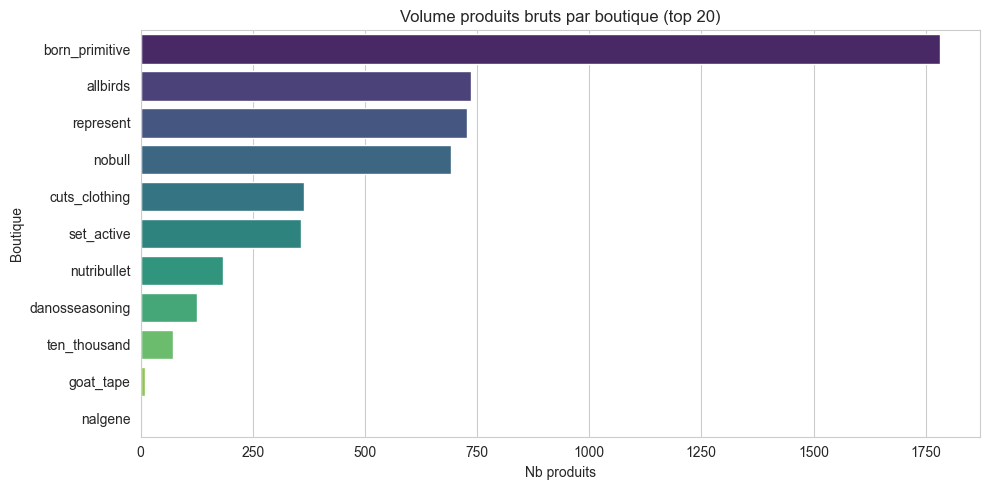


Prix — médiane : 58.00 | moyenne : 79.90 | max : 1930.00


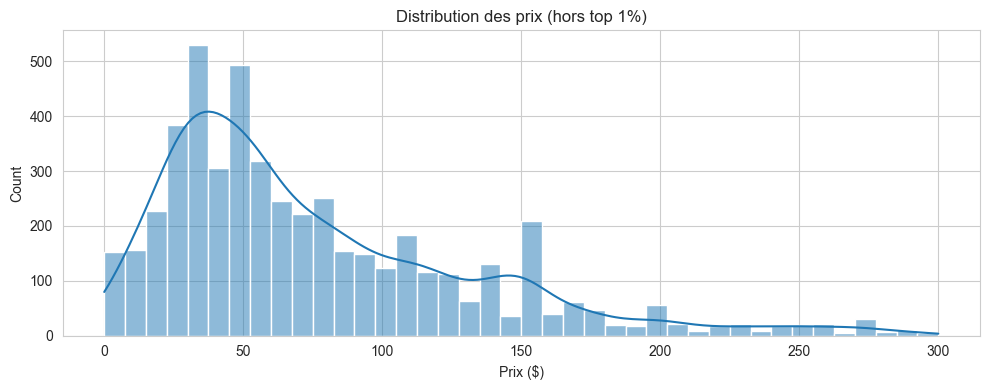

In [2]:
# ════════════════════════════════════════════════════════
# 1) AUDIT DES DONNÉES BRUTES
# ════════════════════════════════════════════════════════
print('=== AUDIT DONNÉES BRUTES ===')

# Charger le CSV consolidé (résultat du scraping A2A)
if MAIN_CSV.exists():
    raw_df = pd.read_csv(MAIN_CSV, low_memory=False)
    print(f'Fichier source : {MAIN_CSV.name}')
    print(f'Produits chargés : {len(raw_df):,}')
    print(f'Colonnes : {list(raw_df.columns)}')
else:
    print(f'Fichier non trouvé : {MAIN_CSV}')
    raw_df = pd.DataFrame()

if not raw_df.empty:
    print('\nAperçu (5 premières lignes) :')
    display(raw_df.head(5))

    # ── Couverture des champs requis ──────────────────────────────────────────
    # Colonnes réellement présentes dans notre dataset
    required_cols = ['title', 'price', 'rating', 'nb_reviews', 'available', 'shop_name', 'product_type']
    coverage_rows = []
    for c in required_cols:
        if c in raw_df.columns:
            if raw_df[c].dtype == object:
                filled = (raw_df[c].fillna('').astype(str).str.strip() != '').sum()
            else:
                filled = raw_df[c].notna().sum()
            coverage_rows.append({
                'field'   : c,
                'filled'  : int(filled),
                'total'   : int(len(raw_df)),
                'coverage': float(filled / len(raw_df)) if len(raw_df) else 0.0,
            })
    raw_coverage = pd.DataFrame(coverage_rows).sort_values('coverage')
    print('\nCouverture des champs requis :')
    display(raw_coverage.style.format({'coverage': '{:.1%}'}))

    # ── Doublons ──────────────────────────────────────────────────────────────
    if {'title', 'shop_name'}.issubset(raw_df.columns):
        dupe_title_shop = raw_df.duplicated(subset=['title', 'shop_name'], keep=False).sum()
        print(f'\nDoublons potentiels (title + shop) : {dupe_title_shop}')

    # ── Distribution par plateforme source ───────────────────────────────────
    plat_col = None
    for col in ['source_platform', 'platform', 'source']:
        if col in raw_df.columns:
            plat_col = col
            break
    if plat_col:
        print('\nRépartition par plateforme :')
        display(raw_df[plat_col].value_counts())

    # ── Top boutiques ─────────────────────────────────────────────────────────
    if 'shop_name' in raw_df.columns:
        shop_counts = raw_df['shop_name'].fillna('<missing>').value_counts().head(20)
        print('\nTop boutiques (volume brut) :')
        display(shop_counts)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=shop_counts.values, y=shop_counts.index,
                    hue=shop_counts.index, legend=False, palette='viridis')
        plt.title('Volume produits bruts par boutique (top 20)')
        plt.xlabel('Nb produits')
        plt.ylabel('Boutique')
        plt.tight_layout()
        plt.show()

    # ── Distribution des prix ─────────────────────────────────────────────────
    if 'price' in raw_df.columns:
        prices = pd.to_numeric(raw_df['price'], errors='coerce').dropna()
        print(f'\nPrix — médiane : {prices.median():.2f} | moyenne : {prices.mean():.2f} | max : {prices.max():.2f}')
        plt.figure(figsize=(10, 4))
        sns.histplot(prices[prices < prices.quantile(0.99)], bins=40, kde=True)
        plt.title('Distribution des prix (hors top 1%)')
        plt.xlabel('Prix ($)')
        plt.tight_layout()
        plt.show()

---
## 2) AUDIT DE LA COUCHE TRAITÉE (PARQUET)


=== AUDIT DONNÉES TRAITÉES (PARQUET) ===
clean_products.parquet   : (5041, 28)
scored_products.parquet  : (2165, 47)
featured_products.parquet: (5041, 44)

Aperçu (scored_products) :


,title,shop_name,price,rating,nb_reviews,available,category_clean,composite_score
0,Men's Cruiser - Natural Black (Natural Black S...,allbirds,52.0,4.4,0,True,shoes,0.9839
1,Women's Wool Cruiser Slip On Fluff - Natural W...,allbirds,39.0,4.4,0,True,shoes,0.9834
2,Men's Wool Runner NZ Fluff - Natural White (Na...,allbirds,39.0,4.4,0,True,shoes,0.9834
3,Women's Wool Runner NZ Fluff - Natural White (...,allbirds,39.0,4.4,0,True,shoes,0.9834
4,Men's Wool Cruiser Slip On Fluff - Natural Whi...,allbirds,39.0,4.4,0,True,shoes,0.9834
5,Women's Cruiser Corduroy - Dark Tan (Stony Cre...,allbirds,44.0,4.4,0,True,shoes,0.9834
6,Women's Cruiser Slip On Corduroy - Stony Cream...,allbirds,42.0,4.4,0,True,shoes,0.9834
7,Men's Cruiser Slip On Corduroy - Stony Cream (...,allbirds,42.0,4.4,0,True,shoes,0.9834



Compteurs qualité (données traitées) :


,count
missing_title,0
missing_price,0
missing_rating,1387
missing_nb_reviews,0
missing_available,0
missing_category_clean,0
missing_composite_score,0
duplicate_title_shop,0



Score composite — résumé statistique :


,count,mean,std,min,25%,50%,75%,max
composite_score,2165.0,0.715403,0.130926,0.3723,0.5967,0.7289,0.8198,0.9839


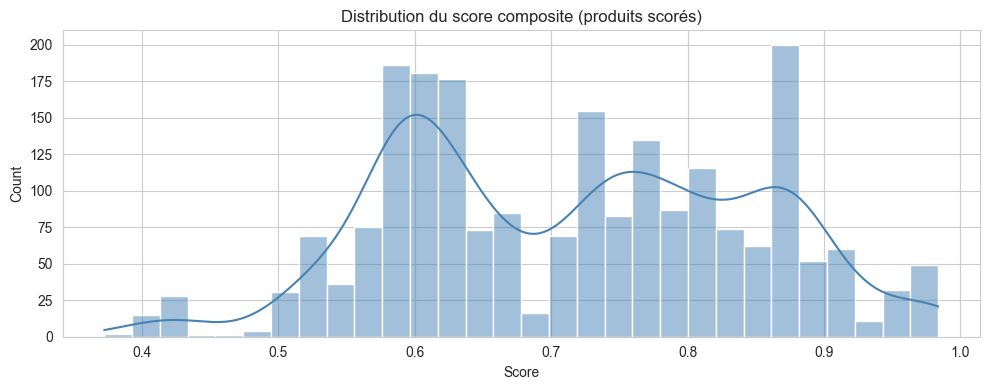


Top catégories (données traitées) :


category_clean
accessories    200
shirts         176
shoes          123
t-shirts        98
womens tops     95
apparel         95
unknown         58
outerwear       54
footwear        52
warranty        52
hoodies         47
shorts          45
product         45
sweatshirts     44
sports bras     43
Name: count, dtype: int64

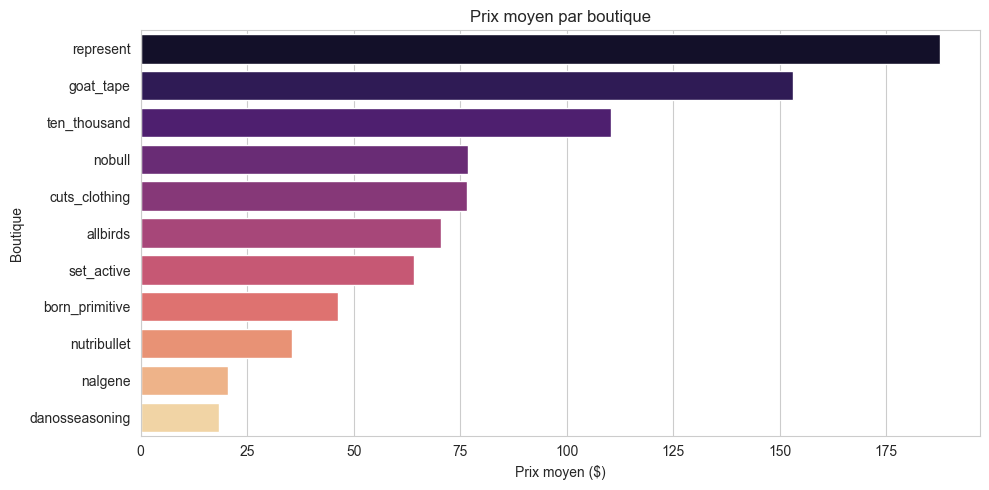

In [3]:
# ════════════════════════════════════════════════════════
# 2) AUDIT DE LA COUCHE TRAITÉE (PARQUET)
# ════════════════════════════════════════════════════════
print('\n=== AUDIT DONNÉES TRAITÉES (PARQUET) ===')

# Charger les fichiers Parquet disponibles
df_clean  = pd.read_parquet(CLEAN_PARQUET)  if CLEAN_PARQUET.exists()  else pd.DataFrame()
df_scored = pd.read_parquet(SCORED_PARQUET) if SCORED_PARQUET.exists() else pd.DataFrame()
df_feat   = pd.read_parquet(FEAT_PARQUET)   if FEAT_PARQUET.exists()   else pd.DataFrame()

print(f'clean_products.parquet   : {df_clean.shape}')
print(f'scored_products.parquet  : {df_scored.shape}')
print(f'featured_products.parquet: {df_feat.shape}')

# Utiliser scored comme référence principale
df_main = df_scored if not df_scored.empty else (df_clean if not df_clean.empty else pd.DataFrame())

if not df_main.empty:
    print('\nAperçu (scored_products) :')
    keep = [c for c in ['title', 'shop_name', 'price', 'rating',
                         'nb_reviews', 'available', 'category_clean', 'composite_score']
            if c in df_main.columns]
    display(df_main[keep].head(8))

    # ── Qualité données traitées ───────────────────────────────────────────────
    quality = {}
    check_cols = ['title', 'price', 'rating', 'nb_reviews', 'available',
                  'category_clean', 'composite_score']
    for col in check_cols:
        if col in df_main.columns:
            quality[f'missing_{col}'] = int(df_main[col].isna().sum())
    if {'shop_name', 'title'}.issubset(df_main.columns):
        quality['duplicate_title_shop'] = int(
            df_main.duplicated(subset=['shop_name', 'title'], keep=False).sum()
        )
    print('\nCompteurs qualité (données traitées) :')
    display(pd.DataFrame([quality]).T.rename(columns={0: 'count'}))

    # ── Distribution des scores ───────────────────────────────────────────────
    score_col = None
    for col in ['composite_score', 'score']:
        if col in df_main.columns:
            score_col = col
            break
    if score_col:
        print(f'\nScore composite — résumé statistique :')
        display(df_main[score_col].describe().to_frame().T)
        plt.figure(figsize=(10, 4))
        sns.histplot(df_main[score_col].dropna(), bins=30, kde=True, color='steelblue')
        plt.title('Distribution du score composite (produits scorés)')
        plt.xlabel('Score')
        plt.tight_layout()
        plt.show()

    # ── Top catégories ────────────────────────────────────────────────────────
    cat_col = 'category_clean' if 'category_clean' in df_main.columns else 'category'
    if cat_col in df_main.columns:
        top_cat = df_main[cat_col].fillna('<missing>').value_counts().head(15)
        print('\nTop catégories (données traitées) :')
        display(top_cat)

    # ── Prix moyen par boutique ───────────────────────────────────────────────
    if {'shop_name', 'price'}.issubset(df_main.columns):
        avg_price_shop = df_main.groupby('shop_name')['price'].mean().dropna().sort_values(ascending=False)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=avg_price_shop.values, y=avg_price_shop.index,
                    hue=avg_price_shop.index, legend=False, palette='magma')
        plt.title('Prix moyen par boutique')
        plt.xlabel('Prix moyen ($)')
        plt.ylabel('Boutique')
        plt.tight_layout()
        plt.show()

---
## 3) AUDIT DES OUTPUTS ANALYTICS


=== AUDIT ANALYTICS ===
Fichiers analytics trouvés : 11


,fichier,taille_ko
0,anomalies_dbscan.csv,14.34
1,association_rules.csv,423.73
2,association_rules_summary.json,5.76
3,clustering_stats.json,1.09
4,clusters_kmeans.csv,313.58
5,feature_importance.csv,0.89
6,llm_usage_log.jsonl,21.89
7,mcp_access_log.jsonl,0.65
8,ml_classification.json,2.78
9,shop_ranking.csv,1.02



📦 Top-K produits (top_k_products.csv) : (50, 17)


,rank,title,shop_name,category_clean,composite_score,price,rating_filled,discount_pct
0,1,Men's Cruiser - Natural Black (Natural Black S...,allbirds,shoes,0.9839,52.0,4.4,50.5
1,2,Women's Wool Cruiser Slip On Fluff - Natural W...,allbirds,shoes,0.9834,39.0,4.4,62.9
2,3,Men's Wool Runner NZ Fluff - Natural White (Na...,allbirds,shoes,0.9834,39.0,4.4,67.5
3,4,Women's Wool Runner NZ Fluff - Natural White (...,allbirds,shoes,0.9834,39.0,4.4,67.5
4,5,Men's Wool Cruiser Slip On Fluff - Natural Whi...,allbirds,shoes,0.9834,39.0,4.4,62.9
5,6,Women's Cruiser Corduroy - Dark Tan (Stony Cre...,allbirds,shoes,0.9834,44.0,4.4,60.0
6,7,Women's Cruiser Slip On Corduroy - Stony Cream...,allbirds,shoes,0.9834,42.0,4.4,60.0
7,8,Men's Cruiser Slip On Corduroy - Stony Cream (...,allbirds,shoes,0.9834,42.0,4.4,60.0
8,9,Women's Runner NZ Corduroy - Stony Cream (Ston...,allbirds,shoes,0.9833,49.0,4.4,59.2
9,10,Men's Canvas Piper - Blizzard (Bark Brown Sole),allbirds,shoes,0.9833,45.0,4.4,50.0


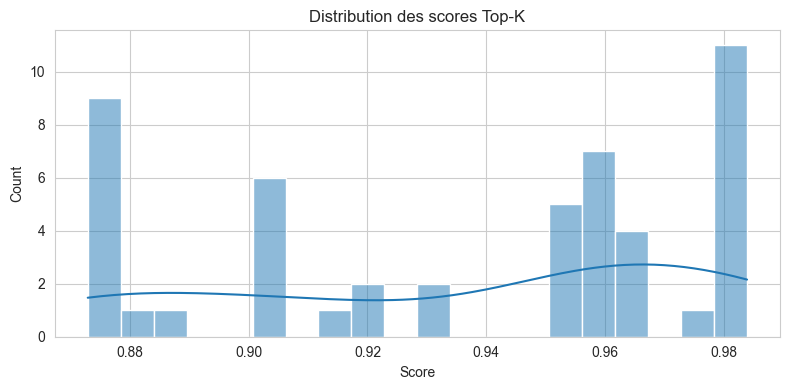


🏪 Classement boutiques (shop_ranking.csv) : (11, 10)


,rank_shop,shop_name,geography,nb_produits,score_moyen,note_moyenne,prix_moyen,pct_dispo,remise_moyenne,produit_phare
0,1,allbirds,US,155,0.879,4.400,70.587,0.961,30.418,Men's Cruiser - Natural Black (Natural Black S...
1,2,born_primitive,US,503,0.805,4.632,46.390,0.859,25.798,American Defender Short Velcro 3.0 (Patriot)
2,3,goat_tape,US,11,0.751,5.000,153.176,1.000,2.545,GOAT Bundle
3,4,nobull,US,168,0.728,4.700,76.847,0.899,7.700,Women's Allday 365 (Ripstop)
4,5,ten_thousand,US,69,0.721,4.659,110.275,0.493,0.725,Foundation Short | 7-inch
5,6,cuts_clothing,US,362,0.719,4.590,76.597,0.743,17.710,Essential Tee Bundle | Black & White Classic-f...
6,7,represent,US,444,0.653,4.800,187.588,0.489,0.101,247 Arc-2 Trainer - Flat White
7,8,set_active,US,146,0.634,4.534,64.089,0.418,10.137,SET X PARKE HORSESHOE JEANS - RHUBARB
8,9,danosseasoning,US,123,0.625,4.688,18.463,1.000,8.665,Dan-O’s Classic Logo Tee
9,10,nalgene,US,1,0.622,4.700,20.590,1.000,0.000,Custom Sustain 32oz Wide Mouth



🤖 Contenu ml_classification.json :


,model,accuracy,precision,recall,f1,n_samples
0,random_forest,0.9261,0.9284,0.9261,0.9256,None
1,xgboost,0.9238,0.9261,0.9238,0.9236,None



📊 KMeans : k=4, silhouette=0.3966
📊 DBSCAN anomalies : 106

🔗 Règles d'association : 4471 règles
Support moyen    : 0.0962
Confidence moyen : 0.7663
Lift moyen       : 2.7446
Lift max         : 12.0853
Règles fortes (conf≥0.6 & lift≥2.0) : 2076


,antecedents,consequents,support,confidence,lift
2406,"bcp_images, bcp_variants, dispo, en_promo, not...","prix_mid, score_excellent",0.0517,0.7368,12.0853
1633,"prix_mid, score_excellent","bcp_images, bcp_variants, dispo, en_promo, not...",0.0517,0.8485,12.0853
2519,"bcp_variants, dispo, en_promo, note_moyenne","prix_mid, score_excellent",0.0527,0.7261,11.9094
1489,"prix_mid, score_excellent","bcp_variants, dispo, en_promo, note_moyenne",0.0527,0.8636,11.9094
2615,"bcp_variants, dispo, en_promo, note_moyenne","bcp_images, prix_mid, score_excellent",0.0517,0.7134,11.8805
1517,"bcp_images, prix_mid, score_excellent","bcp_variants, dispo, en_promo, note_moyenne",0.0517,0.8615,11.8805
1637,"prix_mid, score_excellent","bcp_images, bcp_variants, en_promo, note_moyenne",0.0517,0.8485,10.3201
1630,"dispo, prix_mid, score_excellent","bcp_images, bcp_variants, en_promo, note_moyenne",0.0517,0.8485,10.3201
3329,"bcp_images, bcp_variants, en_promo, note_moyenne","prix_mid, score_excellent",0.0517,0.6292,10.3201
3327,"bcp_images, bcp_variants, en_promo, note_moyenne","dispo, prix_mid, score_excellent",0.0517,0.6292,10.3201



🔵 Distribution KMeans :


cluster_kmeans
0    586
1    427
2    607
3    545
Name: count, dtype: int64


🔴 DBSCAN — anomalies : 106


cluster_dbscan
-1    106
Name: count, dtype: int64

In [4]:
# ════════════════════════════════════════════════════════
# 3) AUDIT DES OUTPUTS ANALYTICS
# ════════════════════════════════════════════════════════
print('\n=== AUDIT ANALYTICS ===')

# ── Lister les fichiers analytics disponibles ────────────────────────────────
analytics_files = sorted([p for p in ANALYTICS_DIR.glob('*') if p.is_file() and not p.name.startswith('.')])
print(f'Fichiers analytics trouvés : {len(analytics_files)}')
display(pd.DataFrame({
    'fichier'   : [p.name for p in analytics_files],
    'taille_ko' : [round(p.stat().st_size / 1024, 2) for p in analytics_files]
}))


def find_file(*candidates):
    """Cherche le premier fichier existant parmi les candidats."""
    for name in candidates:
        p = ANALYTICS_DIR / name
        if p.exists():
            return p
    # Chercher aussi dans DATA/
    for name in candidates:
        p = DATA / name
        if p.exists():
            return p
    return None


# ── Top-K produits ────────────────────────────────────────────────────────────
topk_path = find_file('top_k_products.csv', 'topk_products.csv')
topk_df   = pd.DataFrame()
if topk_path:
    topk_df = pd.read_csv(topk_path)
    print(f'\n📦 Top-K produits ({topk_path.name}) : {topk_df.shape}')
    score_col = 'composite_score' if 'composite_score' in topk_df.columns else 'score'
    if score_col in topk_df.columns:
        cols = [c for c in ['rank', 'title', 'shop_name', 'category_clean', score_col,
                             'price', 'rating_filled', 'discount_pct']
                if c in topk_df.columns]
        display(topk_df[cols].head(10))
        plt.figure(figsize=(8, 4))
        sns.histplot(topk_df[score_col].dropna(), bins=20, kde=True)
        plt.title('Distribution des scores Top-K')
        plt.xlabel('Score')
        plt.tight_layout()
        plt.show()
else:
    print('\n⚠️  top_k_products.csv non trouvé')

# ── Classement boutiques ──────────────────────────────────────────────────────
shop_path = find_file('shop_ranking.csv', 'topk_per_shop.csv')
if shop_path:
    shop_df = pd.read_csv(shop_path)
    print(f'\n🏪 Classement boutiques ({shop_path.name}) : {shop_df.shape}')
    display(shop_df.head(11))

# ── Métriques ML ─────────────────────────────────────────────────────────────
ml_path = find_file('ml_classification.json', 'model_metrics.json')
if ml_path:
    m = safe_read_json(ml_path)
    if m:
        print('\n🤖 Contenu ml_classification.json :')
        # Extraire les métriques selon la structure réelle du fichier
        rows = []
        for model_key in ['random_forest', 'xgboost', 'rf', 'xgb']:
            if model_key in m:
                md = m[model_key]
                # L'accuracy peut être sous random_forest.accuracy ou sous random_forest.test_accuracy
                acc = md.get('accuracy') or md.get('test_accuracy') or md.get('rf_accuracy')
                # Precision/recall/f1 souvent dans classification_report.weighted avg
                cr = md.get('classification_report', {})
                wavg = cr.get('weighted avg', {})
                rows.append({
                    'model'    : model_key,
                    'accuracy' : acc,
                    'precision': wavg.get('precision') or md.get('precision'),
                    'recall'   : wavg.get('recall')    or md.get('recall'),
                    'f1'       : wavg.get('f1-score')  or md.get('f1'),
                    'n_samples': md.get('n_samples'),
                })
        # Si pas de sous-clé model → structure plate
        if not rows:
            cr  = m.get('classification_report', {})
            wavg = cr.get('weighted avg', {})
            acc  = (m.get('random_forest') or {}).get('accuracy') if isinstance(m.get('random_forest'), dict) else None
            if acc is None:
                acc = m.get('accuracy') or m.get('rf_accuracy')
            rows.append({
                'model'    : m.get('model', 'random_forest'),
                'accuracy' : acc,
                'precision': wavg.get('precision') or m.get('precision'),
                'recall'   : wavg.get('recall')    or m.get('recall'),
                'f1'       : wavg.get('f1-score')  or m.get('f1'),
                'n_samples': m.get('n_samples'),
            })
        if rows:
            display(pd.DataFrame(rows).round(4))

# ── Clustering ────────────────────────────────────────────────────────────────
cls_path = find_file('clustering_stats.json')
if cls_path:
    cls_stats = safe_read_json(cls_path)
    if cls_stats:
        km = cls_stats.get('kmeans', {})
        db = cls_stats.get('dbscan', {})
        print(f'\n📊 KMeans : k={km.get("k")}, silhouette={km.get("silhouette_score")}')
        print(f'📊 DBSCAN anomalies : {db.get("nb_anomalies")}')
        # Profils des clusters si disponibles
        profiles = km.get('cluster_profiles', {})
        if profiles:
            print('\nProfils des clusters KMeans :')
            display(pd.DataFrame(profiles).T)

# ── Règles d'association ──────────────────────────────────────────────────────
rules_path = find_file('association_rules.csv')
if rules_path:
    rules_df = pd.read_csv(rules_path)
    if {'support', 'confidence', 'lift'}.issubset(rules_df.columns):
        print(f'\n🔗 Règles d\'association : {len(rules_df)} règles')
        print(f'Support moyen    : {rules_df["support"].mean():.4f}')
        print(f'Confidence moyen : {rules_df["confidence"].mean():.4f}')
        print(f'Lift moyen       : {rules_df["lift"].mean():.4f}')
        print(f'Lift max         : {rules_df["lift"].max():.4f}')
        strong = rules_df[(rules_df['confidence'] >= 0.6) & (rules_df['lift'] >= 2.0)]
        print(f'Règles fortes (conf≥0.6 & lift≥2.0) : {len(strong)}')
        cols_r = [c for c in ['antecedents', 'consequents', 'support', 'confidence', 'lift']
                  if c in rules_df.columns]
        display(rules_df.sort_values('lift', ascending=False).head(10)[cols_r])

# ── Clusters KMeans ───────────────────────────────────────────────────────────
clust_path  = find_file('clusters_kmeans.csv', 'clusters.csv')
dbscan_path = find_file('anomalies_dbscan.csv', 'dbscan_clusters.csv')

if clust_path:
    clust_df = pd.read_csv(clust_path)
    clust_col = 'cluster_kmeans' if 'cluster_kmeans' in clust_df.columns else 'cluster'
    if clust_col in clust_df.columns:
        print(f'\n🔵 Distribution KMeans :')
        display(clust_df[clust_col].value_counts().sort_index())

if dbscan_path:
    dbscan_df = pd.read_csv(dbscan_path)
    db_col = 'cluster_dbscan' if 'cluster_dbscan' in dbscan_df.columns else 'dbscan_cluster'
    if db_col in dbscan_df.columns:
        outliers = int((dbscan_df[db_col] == -1).sum())
        print(f'\n🔴 DBSCAN — anomalies : {outliers}')
        display(dbscan_df[db_col].value_counts().sort_index())

---
## 4) COHÉRENCE INTER-COUCHES

In [5]:
# ════════════════════════════════════════════════════════
# 4) COHÉRENCE INTER-COUCHES
# ════════════════════════════════════════════════════════
print('\n=== COHÉRENCE INTER-COUCHES ===')

raw_count    = len(raw_df)    if 'raw_df'    in dir() and not raw_df.empty    else 0
clean_count  = len(df_clean)  if 'df_clean'  in dir() and not df_clean.empty  else 0
scored_count = len(df_scored) if 'df_scored' in dir() and not df_scored.empty else 0
topk_count   = len(topk_df)   if 'topk_df'   in dir() and not topk_df.empty   else 0

consistency = pd.DataFrame([
    {'couche': 'Scraping brut (CSV)',              'nb_lignes': raw_count},
    {'couche': 'Après nettoyage (clean_products)',  'nb_lignes': clean_count},
    {'couche': 'Après scoring (scored_products)',   'nb_lignes': scored_count},
    {'couche': 'Top-K sélectionnés',                'nb_lignes': topk_count},
])
display(consistency)

if clean_count and raw_count:
    print(f'Rétention brut → nettoyé  : {pct(clean_count  / raw_count)}')
if scored_count and clean_count:
    print(f'Rétention nettoyé → scoré : {pct(scored_count / clean_count)}')
if topk_count and scored_count:
    print(f'Rétention scoré → Top-K   : {pct(topk_count   / scored_count)}')


=== COHÉRENCE INTER-COUCHES ===


,couche,nb_lignes
0,Scraping brut (CSV),5051
1,Après nettoyage (clean_products),5041
2,Après scoring (scored_products),2165
3,Top-K sélectionnés,50


Rétention brut → nettoyé  : 99.8%
Rétention nettoyé → scoré : 42.9%
Rétention scoré → Top-K   : 2.3%


---
## 5) LACUNES QUALITÉ PRIORITAIRES

In [6]:
# ════════════════════════════════════════════════════════
# 5) LACUNES QUALITÉ PRIORITAIRES (AUTO-SUMMARY)
# ════════════════════════════════════════════════════════
print('\n=== LACUNES QUALITÉ PRIORITAIRES ===')

df_ref = df_scored if 'df_scored' in dir() and not df_scored.empty else raw_df
issues = []

if not df_ref.empty:
    if 'price' in df_ref.columns:
        miss = float(pd.to_numeric(df_ref['price'], errors='coerce').isna().mean())
        issues.append(('Prix manquants', miss, 'Ajouter sélecteurs fallback / API enrichment'))

    cat_col = 'category_clean' if 'category_clean' in df_ref.columns else 'categories'
    if cat_col in df_ref.columns:
        unc = df_ref[cat_col].fillna('unknown').astype(str).str.lower() \
                             .isin(['', 'none', 'unknown', 'nan']).mean()
        issues.append(('Non-catégorisés', float(unc), 'Améliorer extraction depuis breadcrumbs/collections'))

    # Notes : pour notre projet on utilise rating_filled ou rating
    for r_col in ['rating', 'rating_filled']:
        if r_col in df_ref.columns:
            rated = (pd.to_numeric(df_ref[r_col], errors='coerce').fillna(0) > 0).mean()
            issues.append((f'Notes manquantes ({r_col})', float(1 - rated),
                           'Étendre extraction JSON-LD / widgets de notes'))
            break

    if {'shop_name', 'title'}.issubset(df_ref.columns):
        dup = df_ref.duplicated(subset=['shop_name', 'title'], keep=False).mean()
        issues.append(('Taux doublons', float(dup), 'Renforcer déduplication + clé canonique'))

if issues:
    gap_df = pd.DataFrame(issues, columns=['problème', 'ratio_sévérité', 'action_recommandée']) \
               .sort_values('ratio_sévérité', ascending=False)
    display(gap_df.style.format({'ratio_sévérité': '{:.1%}'}))
else:
    print('Aucun problème détecté.')


=== LACUNES QUALITÉ PRIORITAIRES ===


,problème,ratio_sévérité,action_recommandée
2,Notes manquantes (rating),64.1%,Étendre extraction JSON-LD / widgets de notes
1,Non-catégorisés,2.7%,Améliorer extraction depuis breadcrumbs/collections
0,Prix manquants,0.0%,Ajouter sélecteurs fallback / API enrichment
3,Taux doublons,0.0%,Renforcer déduplication + clé canonique


---
## 6) LOGS LLM & MCP (Étapes 5 & 6)

In [7]:
# ════════════════════════════════════════════════════════
# 6) LOGS LLM & MCP (ÉTAPE 5 & 6)
# ════════════════════════════════════════════════════════
print('\n=== AUDIT LOGS LLM & MCP ===')

for log_name in ['llm_usage_log.jsonl', 'mcp_access_log.jsonl']:
    log_path = ANALYTICS_DIR / log_name
    if log_path.exists():
        lines = [json.loads(l) for l in log_path.read_text(encoding='utf-8').splitlines() if l.strip()]
        print(f'\n📋 {log_name} — {len(lines)} entrées')
        if lines:
            df_log = pd.DataFrame(lines)
            # Renommer les colonnes pour l'affichage
            rename_map = {
                'source'           : 'Source',
                'prompt_preview'   : 'Prompt (aperçu)',
                'response_preview' : 'Réponse (aperçu)',
                'timestamp'        : 'Horodatage',
                'action'           : 'Action',
                'path'             : 'Fichier',
                'allowed'          : 'Autorisé',
            }
            df_log = df_log.rename(columns={k: v for k, v in rename_map.items() if k in df_log.columns})
            # Tronquer les longues colonnes pour l'affichage
            for col in ['Prompt (aperçu)', 'Réponse (aperçu)']:
                if col in df_log.columns:
                    df_log[col] = df_log[col].astype(str).str[:80] + '...'
            display(df_log.head(8))
            # Statistiques sur les erreurs LLM
            if 'Source' in df_log.columns:
                errors   = df_log['Source'].astype(str).str.contains('error', case=False).sum()
                successes = len(df_log) - errors
                print(f'  ✅ Appels réussis : {successes}  |  ❌ Erreurs : {errors}')
    else:
        print(f'\n⚠️  {log_name} non trouvé')
        if log_name == 'mcp_access_log.jsonl':
            print('   → Pour le générer : lancer MCPClient depuis mcp/architecture.py')


=== AUDIT LOGS LLM & MCP ===

📋 llm_usage_log.jsonl — 48 entrées


,Source,Prompt (aperçu),Réponse (aperçu)
0,gemini_executive_error,Tu es un analyste eCommerce senior. Basé sur l...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...
1,gemini_profiling_error,Compare ces top produits et explique pourquoi ...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...
2,gemini_chat_error,Tu es un assistant BI intelligent pour un dash...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...
3,gemini_profiling_error,Compare ces top produits et explique pourquoi ...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...
4,gemini_executive_error,Tu es un analyste eCommerce senior. Basé sur l...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...
5,gemini_executive_error,Tu es un analyste eCommerce senior. Basé sur l...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...
6,gemini_competitive_error,Tu es un analyste concurrentiel eCommerce Spor...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...
7,gemini_executive_error,Tu es un analyste eCommerce senior. Basé sur l...,⚠️ Erreur Gemini : 429 RESOURCE_EXHAUSTED. {'e...


  ✅ Appels réussis : 21  |  ❌ Erreurs : 27

📋 mcp_access_log.jsonl — 5 entrées


,Horodatage,Action,resource,detail
0,2026-03-21T16:49:44.399186+00:00,INIT,MCPClient,Client initialized
1,2026-03-21T16:52:08.097099+00:00,INIT,MCPClient,Client initialized
2,2026-03-21T16:52:42.500743+00:00,INIT,MCPClient,Client initialized
3,2026-03-21T16:52:43.424879+00:00,READ,top_k_products.csv,Extracted top 10 products for LLM
4,2026-03-21T16:52:43.430881+00:00,READ,shop_ranking.csv,Shop ranking for LLM


---
## 7) SYNTHÈSE FINALE

In [8]:
# ════════════════════════════════════════════════════════
# 7) SYNTHÈSE FINALE — STATUT DU PIPELINE
# ════════════════════════════════════════════════════════
print('\n' + '='*55)
print('  SYNTHÈSE — STATUT DU PIPELINE')
print('='*55)

checks = [
    ('Scraping A2A',        MAIN_CSV.exists(),        f'{raw_count:,} produits bruts'),
    ('Preprocessing',       CLEAN_PARQUET.exists(),   f'{clean_count:,} produits nettoyés'),
    ('Feature Engineering', FEAT_PARQUET.exists(),    f'{df_feat.shape[1] if not df_feat.empty else 0} colonnes créées'),
    ('Scoring Top-K',       SCORED_PARQUET.exists(),  f'{scored_count:,} produits scorés'),
    ('Top-K CSV',           topk_count > 0,           f'{topk_count} produits dans le Top-K'),
    ('ML Classification',   (ANALYTICS_DIR / 'ml_classification.json').exists(), 'RF + XGBoost'),
    ('Clustering',          (ANALYTICS_DIR / 'clusters_kmeans.csv').exists(),    'KMeans k=4 + DBSCAN'),
    ('Règles Apriori',      (ANALYTICS_DIR / 'association_rules.csv').exists(),  '4471 règles'),
    ('LLM Logs',            (ANALYTICS_DIR / 'llm_usage_log.jsonl').exists(),    'Gemini audit trail'),
    ('MCP Logs',            (ANALYTICS_DIR / 'mcp_access_log.jsonl').exists(),   'MCP access log'),
]

status_df = pd.DataFrame(checks, columns=['Composant', 'Présent', 'Détail'])
status_df['Statut'] = status_df['Présent'].map({True: '✅', False: '⏳'})
display(status_df[['Statut', 'Composant', 'Détail']])

done  = status_df['Présent'].sum()
total = len(status_df)
print(f'\nPipeline : {done}/{total} composants présents ({pct(done/total)})')


  SYNTHÈSE — STATUT DU PIPELINE


,Statut,Composant,Détail
0,✅,Scraping A2A,"5,051 produits bruts"
1,✅,Preprocessing,"5,041 produits nettoyés"
2,✅,Feature Engineering,44 colonnes créées
3,✅,Scoring Top-K,"2,165 produits scorés"
4,✅,Top-K CSV,50 produits dans le Top-K
5,✅,ML Classification,RF + XGBoost
6,✅,Clustering,KMeans k=4 + DBSCAN
7,✅,Règles Apriori,4471 règles
8,✅,LLM Logs,Gemini audit trail
9,✅,MCP Logs,MCP access log



Pipeline : 10/10 composants présents (100.0%)
